<a href="https://colab.research.google.com/github/Nikhil5566/Data-Science-Portfolio-Projects/blob/main/Toyota%20Stock%20Prices%201980-2026%20Historical%20Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Toyota Stock Prices: 1980-2026 Historical Data

# Summary & Key-Insights

This dataset provides a fascinating journey through Toyota's stock performance from 1980 to 2026, offering a clean, comprehensive look at its daily prices and trading volumes. The data is remarkably robust, with no missing entries or duplicates, ensuring reliable analysis.

### Key Trends & Market Behavior:

Fundamentally, Toyota's stock has exhibited a strong, consistent **upward trend** over these decades, alongside a general increase in **trading volume**, reflecting its long-term growth and sustained investor interest.

However, a deeper dive into the **daily returns** reveals a crucial insight: they **do not follow a perfect normal distribution**. Instead, the data shows "fat tails," meaning extreme price swings – both positive rallies and significant crashes – occur far more frequently than basic statistical models would predict. This "non-normal" behavior is further underscored by positive **skewness**, indicating that upside moves tend to be more extreme than downturns, and high **kurtosis**, confirming the prevalence of these unusual, impactful events. Despite these quirks, the daily returns are statistically **stationary**, a desirable trait for building robust predictive models, as their underlying statistical properties remain stable over time.

### Risk and Volatility:

The analysis highlights that **volatility in Toyota's stock tends to cluster**. Periods of high market turbulence are often followed by more turbulence, and calm periods by more calm. This suggests distinct "panic" and "calm" regimes in its trading history. Quantifying extreme risk, a **99% Value at Risk (VaR)** indicates that on 99 out of 100 days, the stock won't drop more than approximately 4.60%. However, on the rare "worst 1%" days, the **Conditional VaR (CVaR)** shows an average expected loss closer to 6.30%. Interestingly, the stock's daily returns show **minimal short-term memory**, implying that yesterday's movement has little direct predictive power for today's.

### Future Outlook & Algorithmic Insights:

Sophisticated models, like **GARCH**, effectively map these changing volatility landscapes. A **Hidden Markov Model** further identifies invisible market states, revealing shifts between low and high volatility periods. Looking ahead, **Monte Carlo simulations** forecast a range of possible future prices, projecting an expected mean price around ¥263.60 within a year, but also outlining potential worst-case (5th percentile ~¥158.95) and best-case (95th percentile ~¥407.16) scenarios.

From an algorithmic perspective, the stock has experienced significant drawdowns, including a historical **maximum drawdown of over 60%**, highlighting the importance of capital preservation. Basic algorithmic indicators like MACD and RSI can provide trading signals. When testing a simple **Random Forest Classifier** to predict daily price direction, the model achieved approximately 52.25% accuracy and 53.65% precision on unseen data. While not a dramatic outperformance, it suggests that with further refinement and more complex strategies, there is potential to leverage these insights for an edge over a passive "buy and hold" approach. The algorithmic analysis identified **MACD Histogram**, **Volatility Lag**, and **Distance from SMA 200** as key drivers of the model's predictions.

This comprehensive analysis provides a robust understanding of Toyota's stock from both a traditional and quantitative finance perspective, revealing patterns, risks, and potential avenues for future prediction and strategy development.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d omarshahrukh/toyota-stock-prices-1980-2026-historical-data

# Unziping the downloaded file
!unzip toyota-stock-prices-1980-2026-historical-data.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/omarshahrukh/toyota-stock-prices-1980-2026-historical-data
License(s): CC0-1.0
  0% 0.00/168k [00:00<?, ?B/s]
100% 168k/168k [00:00<00:00, 440MB/s]
Archive:  toyota-stock-prices-1980-2026-historical-data.zip
  inflating: Toyota_Stock_Prices_1980_2026.csv  


# Data Inspection

In [4]:
df = pd.read_csv('Toyota_Stock_Prices_1980_2026.csv')
df.head(11)

,Date,Close,High,Low,Open,Volume
0,1980-03-18,1.8207,1.8501,1.8207,1.8207,9343
1,1980-03-19,1.8207,1.8207,1.8207,1.8207,0
2,1980-03-20,1.8207,1.8501,1.8207,1.8207,10277
3,1980-03-21,1.8649,1.8944,1.8649,1.8649,8409
4,1980-03-24,1.8723,1.9017,1.8723,1.8723,2803
5,1980-03-25,1.8575,1.8870,1.8575,1.8723,27095
6,1980-03-26,1.8575,1.8870,1.8575,1.8575,1869
7,1980-03-27,1.8354,1.8649,1.8354,1.8575,14015
8,1980-03-28,1.8280,1.8575,1.8280,1.8354,36438
9,1980-03-31,1.8280,1.8575,1.8280,1.8280,1869


In [5]:
df.tail(11)

,Date,Close,High,Low,Open,Volume
11497,2026-01-15,232.33,235.64,232.13,234.50,395200
11498,2026-01-16,231.42,232.08,230.71,231.67,235900
11499,2026-01-20,220.47,222.62,220.09,222.50,378100
11500,2026-01-21,227.74,228.46,224.54,224.54,282500
11501,2026-01-22,227.04,228.09,226.73,226.96,232300
11502,2026-01-23,226.28,227.06,225.39,226.81,199000
11503,2026-01-26,225.62,226.24,225.00,225.00,278300
11504,2026-01-27,224.12,225.50,224.11,225.01,287000
11505,2026-01-28,218.89,220.15,217.48,219.18,437600
11506,2026-01-29,227.07,227.32,223.54,225.52,334500


In [6]:
df.shape

(11508, 6)

In [7]:
df.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

In [8]:
df.dtypes

,0
Date,object
Close,float64
High,float64
Low,float64
Open,float64
Volume,int64


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11508 entries, 0 to 11507
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    11508 non-null  object 
 1   Close   11508 non-null  float64
 2   High    11508 non-null  float64
 3   Low     11508 non-null  float64
 4   Open    11508 non-null  float64
 5   Volume  11508 non-null  int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 539.6+ KB


In [10]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date,11508,11508,2026-01-30,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Close,11508.0,NaN,NaN,NaN,56.436218,51.05142,1.7838,15.771775,41.5715,85.989425,243.7641
High,11508.0,NaN,NaN,NaN,56.761133,51.318871,1.7838,15.8795,41.877,86.35925,245.7459
Low,11508.0,NaN,NaN,NaN,56.110388,50.747118,1.7838,15.771775,41.18555,85.5466,242.7877
Open,11508.0,NaN,NaN,NaN,56.444586,51.04703,1.7838,15.8163,41.5639,86.017375,245.2625
Volume,11508.0,NaN,NaN,NaN,219292.868439,385121.165725,0.0,14258.75,105188.0,302925.0,18582700.0


In [12]:
df.isnull().sum()

,0
Date,0
Close,0
High,0
Low,0
Open,0
Volume,0


In [13]:
df.duplicated().sum()

np.int64(0)

# Univariate Analysis

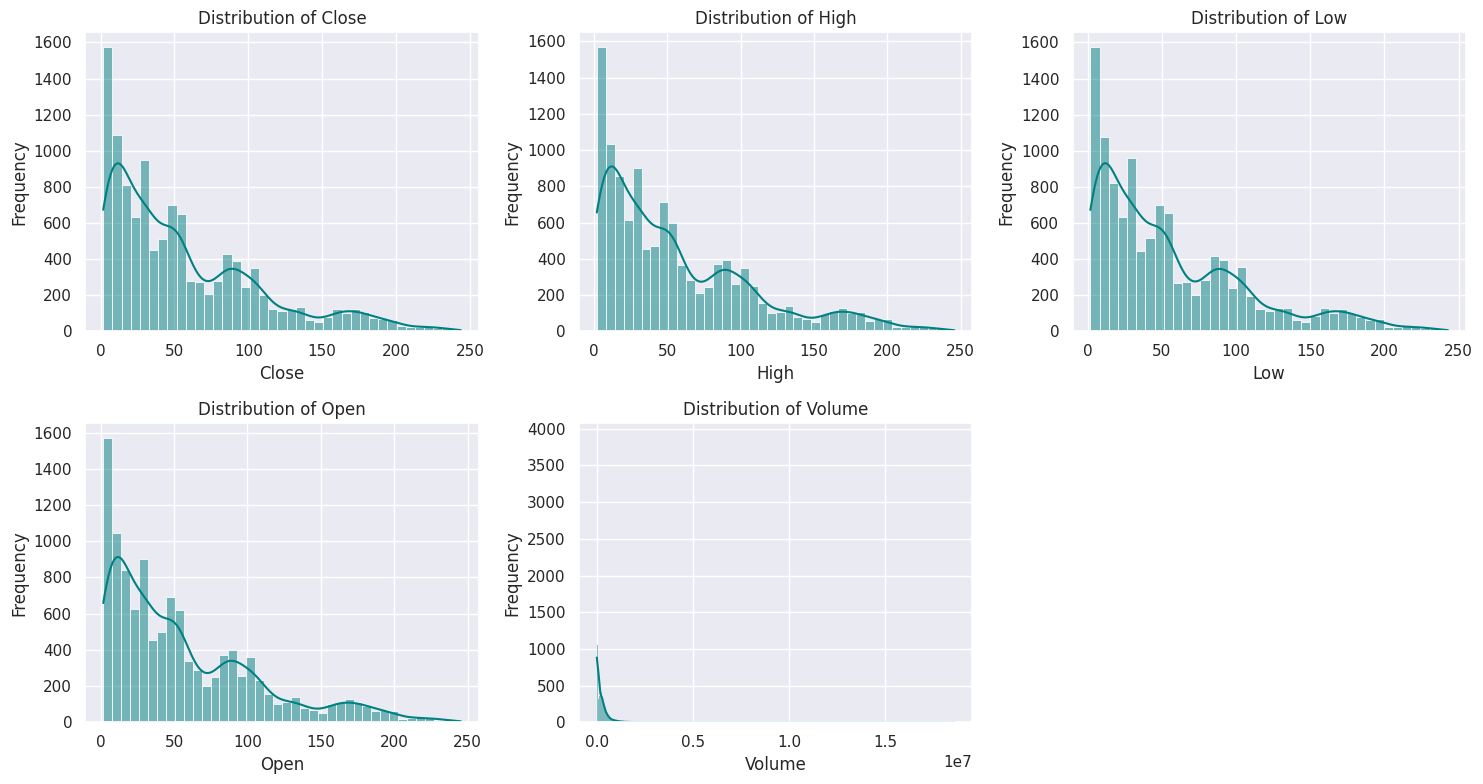

No categorical columns found (or all have high cardinality).


In [15]:
import math

# --- 1. Numerical Columns (Histograms in a Grid) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

if len(numerical_cols) > 0:
    # Defining grid size
    num_plots = len(numerical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterating and plot
    for i, col in enumerate(numerical_cols):
        sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='teal') # Added color
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

    # Hiding any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found.")


# --- 2. Categorical Columns (Countplots in a Grid) ---
# Filtering out columns with too many unique values (like IDs) to avoid messy plots
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 20]

if len(categorical_cols) > 0:
    # Defining grid size
    num_plots = len(categorical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterating and plot
    for i, col in enumerate(categorical_cols):
        sns.countplot(data=df, x=col, ax=axes[i], palette='viridis', hue=col, legend=False) # Added palette
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
        axes[i].tick_params(axis='x', rotation=45)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

     # --- 3. Value Counts (Text Output) ---
    print("--- Categorical Value Counts ---")
    for col in categorical_cols:
        print(f"\nValue counts for {col}:")
        print(df[col].value_counts())
else:
    print("No categorical columns found (or all have high cardinality).")

# Bivariate Analysis

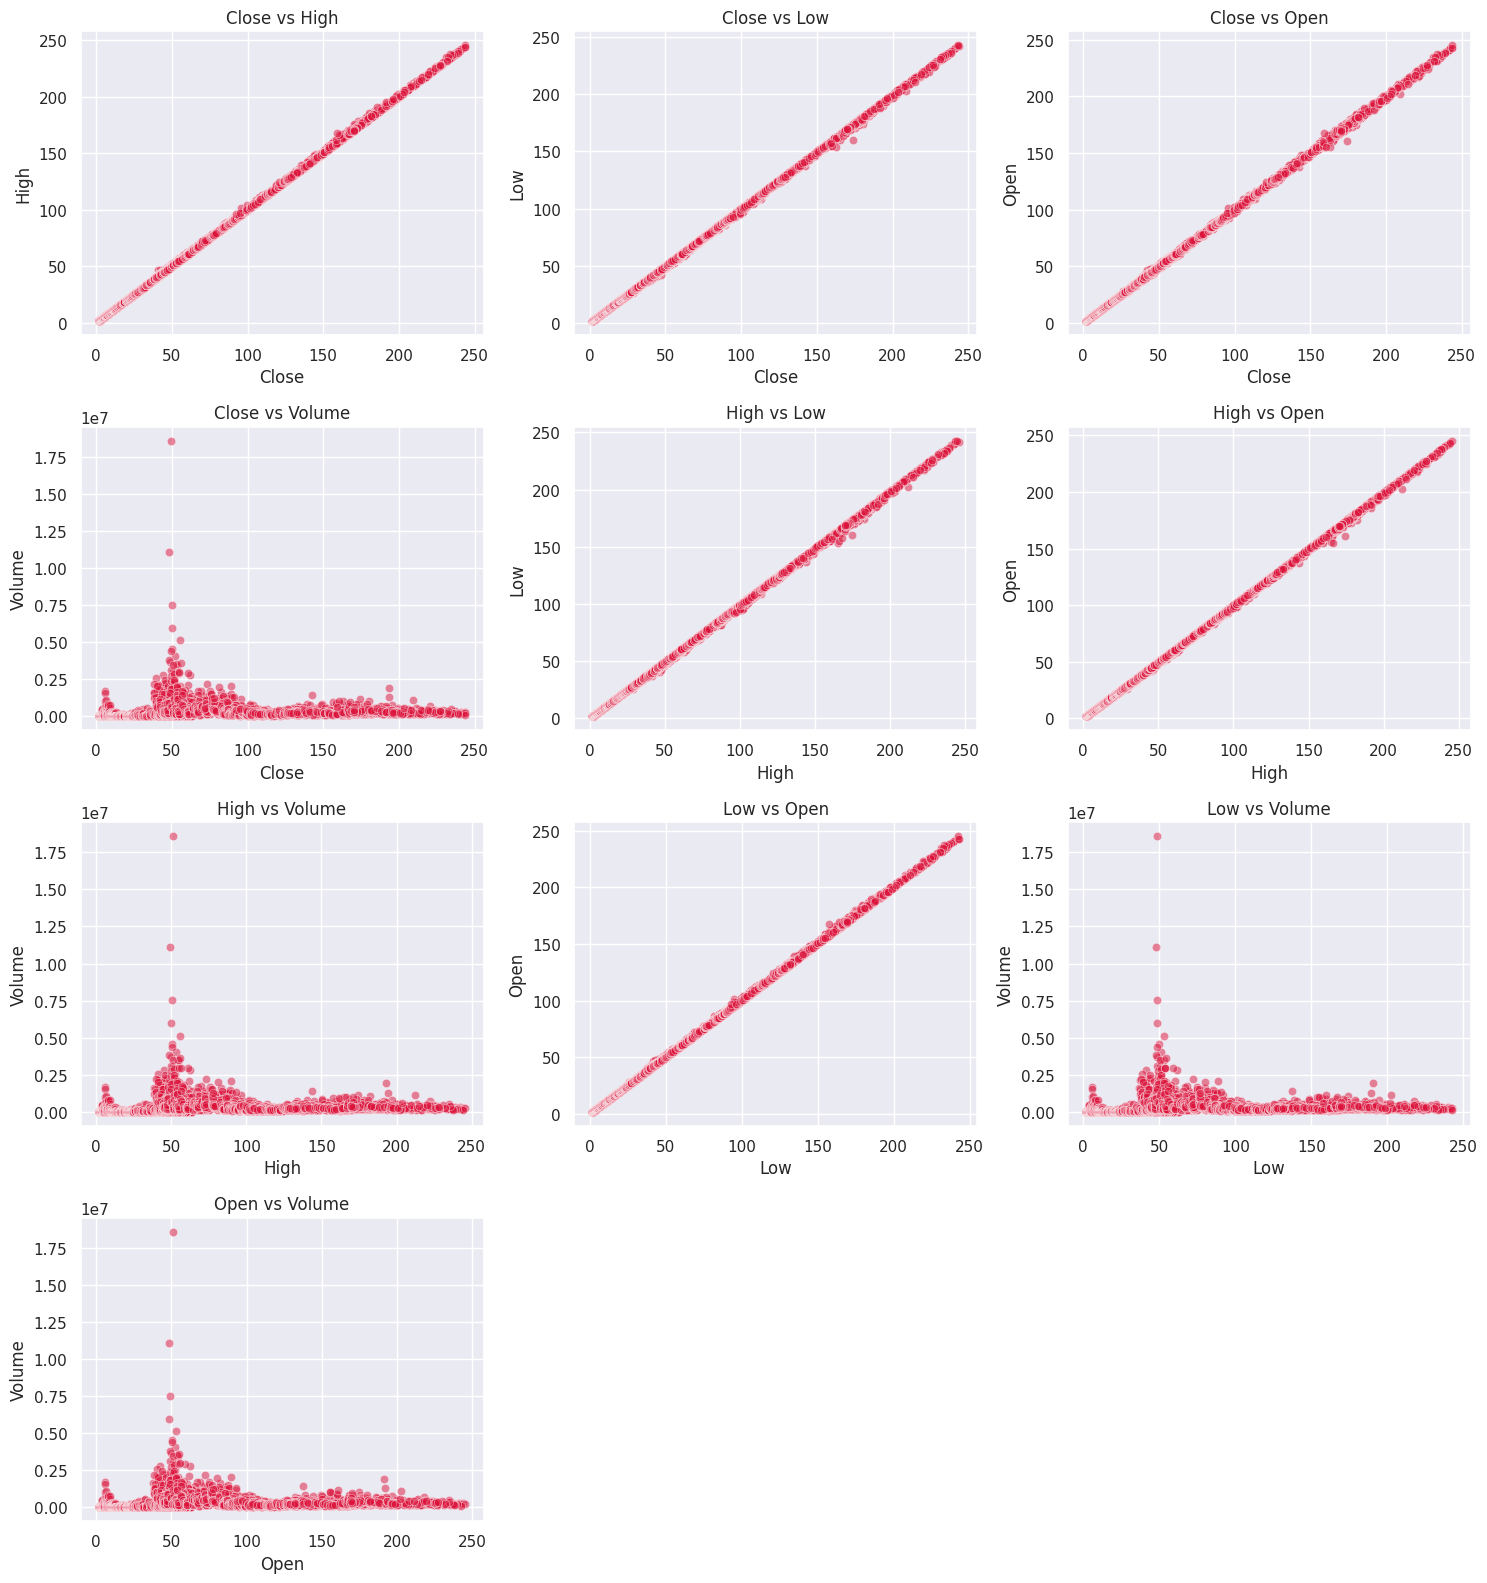

No categorical-numerical pairs found.


In [16]:
import itertools

# --- 1. Numerical-Numerical Relationships (Scatter Plots) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generating all unique pairs of numerical columns
num_pairs = list(itertools.combinations(numerical_cols, 2))

if len(num_pairs) > 0:
    # Defining grid size
    num_plots = len(num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Iterating through pairs and plot
    for i, (col1, col2) in enumerate(num_pairs):
        sns.scatterplot(data=df, x=col1, y=col2, ax=axes[i], alpha=0.5, color='crimson') # Added color
        axes[i].set_title(f'{col1} vs {col2}')
        axes[i].set_xlabel(col1)
        axes[i].set_ylabel(col2)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Not enough numerical columns for scatter plots.")


# --- 2. Categorical-Numerical Relationships (Box Plots) ---
# Excluding high cardinality columns
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 20]
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generating all pairs of (Categorical, Numerical)
cat_num_pairs = list(itertools.product(categorical_cols, numerical_cols))

if len(cat_num_pairs) > 0:
    # Defining grid size
    num_plots = len(cat_num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Iterating through pairs and plot
    for i, (cat_col, num_col) in enumerate(cat_num_pairs):
        sns.boxplot(data=df, x=cat_col, y=num_col, ax=axes[i], palette='Set2', hue=cat_col, legend=False)
        axes[i].set_title(f'{num_col} by {cat_col}')
        axes[i].set_xlabel(cat_col)
        axes[i].set_ylabel(num_col)
        axes[i].tick_params(axis='x', rotation=45)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No categorical-numerical pairs found.")


# --- 3. Categorical-Categorical Relationships (Heatmaps) ---
# Generating pairs of categorical columns
cat_pairs = list(itertools.combinations(categorical_cols, 2))

if len(cat_pairs) > 0:
    num_plots = len(cat_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, (col1, col2) in enumerate(cat_pairs):
        # Creating a cross-tabulation
        crosstab = pd.crosstab(df[col1], df[col2], normalize='index')
        sns.heatmap(crosstab, annot=True, fmt='.2f', cmap='Purples', ax=axes[i])
        axes[i].set_title(f'{col1} vs {col2} (Proportion)')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Multivariate Analysis

In [14]:
import itertools
import math

# --- Multivariate Analysis: Numerical Pairs with Categorical Hue ---

# 1. Identifying valid columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
# Filtering categorical columns to those with few unique values for clear legends (e.g., < 10)
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 10]

# Generating pairs of numerical columns to plot
num_pairs = list(itertools.combinations(numerical_cols, 2))

if len(numerical_cols) > 1 and len(categorical_cols) > 0:
    # OUTER LOOP: Iterating through each categorical variable to use as the 'Hue'
    for cat_col in categorical_cols:
        print(f"\nAnalyzing relationships with Hue: {cat_col}...")

        # Defining grid size for the inner loop (numerical pairs)
        num_plots = len(num_pairs)
        num_cols_plot = 3
        num_rows_plot = math.ceil(num_plots / num_cols_plot)

        # Creating figure
        fig, axes = plt.subplots(num_rows_plot, num_cols_plot, figsize=(15, 4 * num_rows_plot))
        if num_plots > 1:
             axes = axes.flatten()
        else:
             axes = [axes]

        # INNER LOOP: Iterating through numerical pairs
        for i, (num1, num2) in enumerate(num_pairs):
            sns.scatterplot(data=df, x=num1, y=num2, hue=cat_col, ax=axes[i], alpha=0.6)
            axes[i].set_title(f'{num1} vs {num2}')

        # Hiding unused subplots
        for j in range(i + 1, len(axes)):
            axes[j].axis('off')

        plt.suptitle(f'Multivariate Analysis: Colored by {cat_col}', y=1.02, fontsize=16)
        plt.tight_layout()
        plt.show()
        print("="*80)
else:
    print("Not enough data for multivariate scatter analysis (need >1 numerical and >0 categorical columns).")

Not enough data for multivariate scatter analysis (need >1 numerical and >0 categorical columns).


# Pairplot

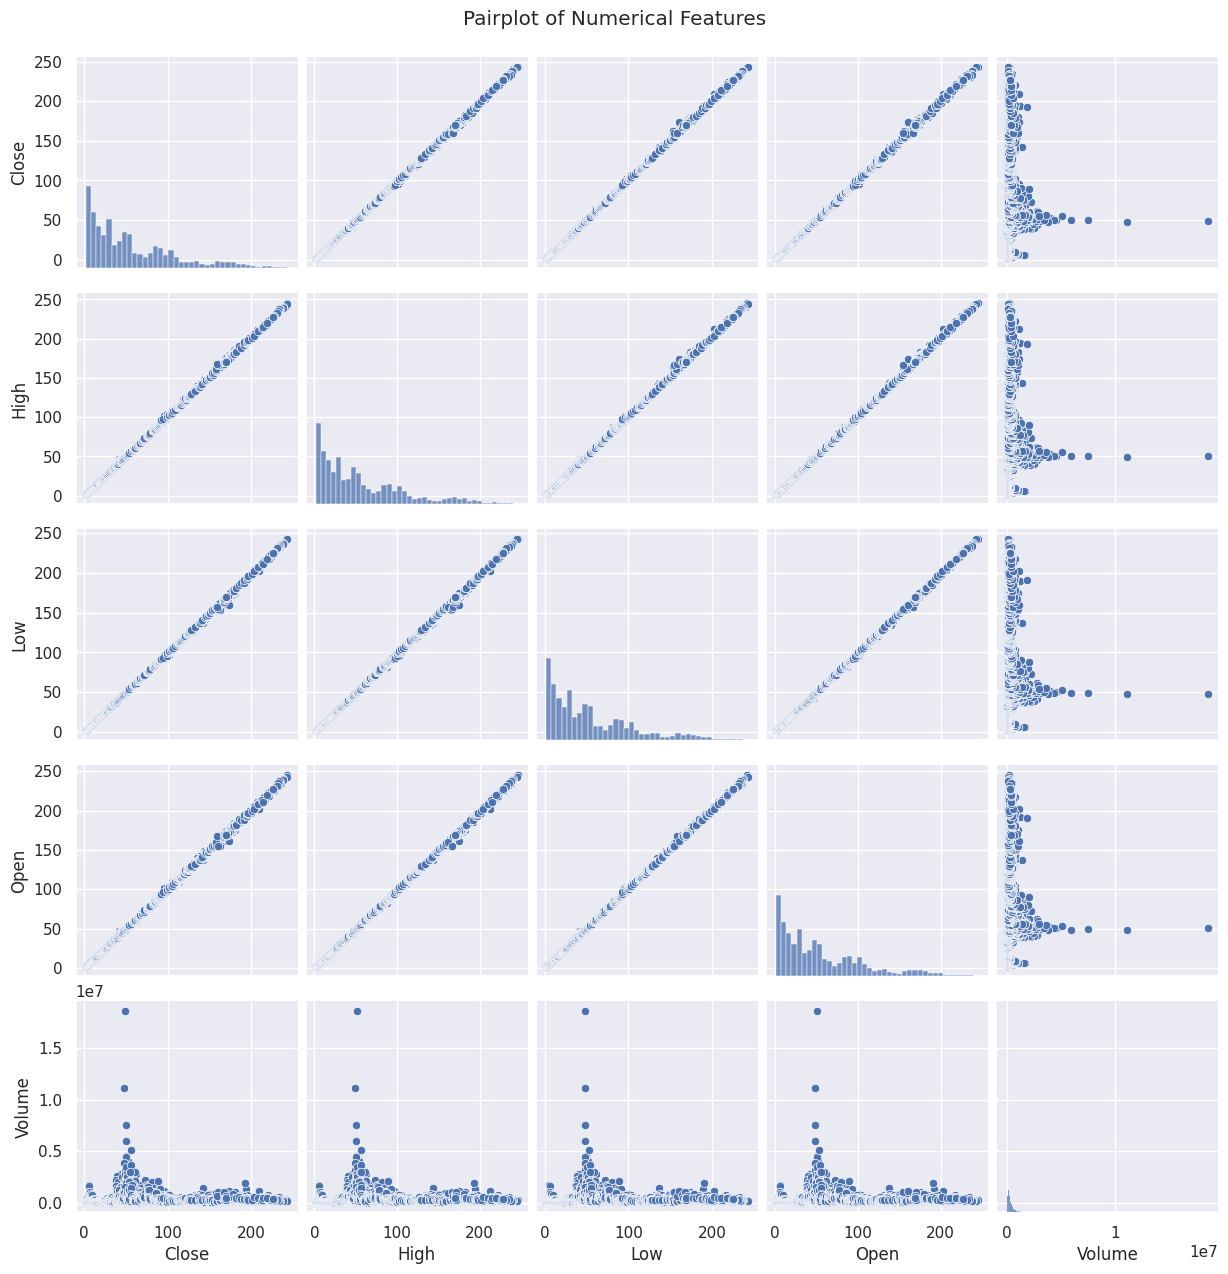

In [21]:
sns.pairplot(df.select_dtypes(include = np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

# Heatmap

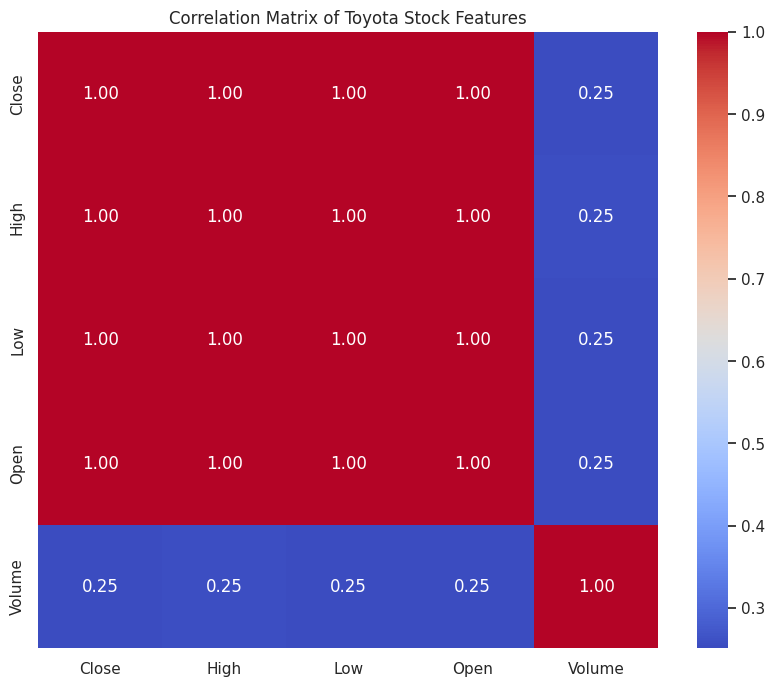

In [20]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Toyota Stock Features')
plt.show()

## Convert Date Column


In [17]:
df['Date'] = pd.to_datetime(df['Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11508 entries, 0 to 11507
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    11508 non-null  datetime64[ns]
 1   Close   11508 non-null  float64       
 2   High    11508 non-null  float64       
 3   Low     11508 non-null  float64       
 4   Open    11508 non-null  float64       
 5   Volume  11508 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 539.6 KB


## Plot Stock Price Trends.


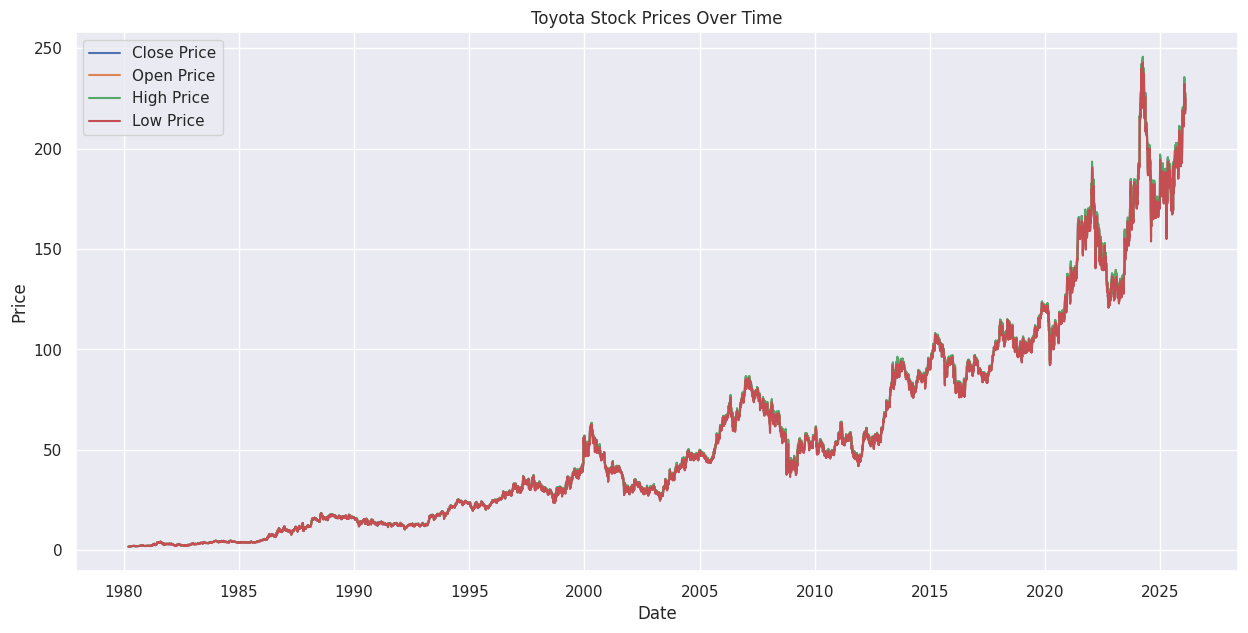

In [18]:
df.set_index('Date', inplace=True)

plt.figure(figsize=(15, 7))
plt.plot(df['Close'], label='Close Price')
plt.plot(df['Open'], label='Open Price')
plt.plot(df['High'], label='High Price')
plt.plot(df['Low'], label='Low Price')

plt.title('Toyota Stock Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

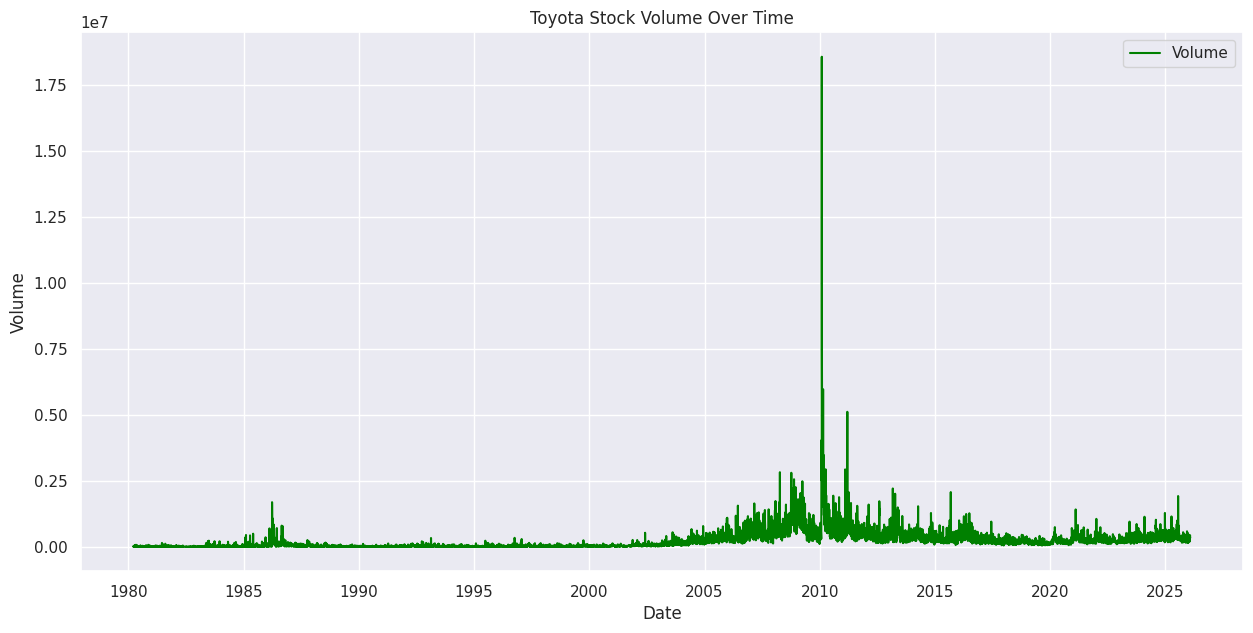

In [19]:
plt.figure(figsize=(15, 7))
plt.plot(df['Volume'], label='Volume', color='green')

plt.title('Toyota Stock Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.legend()
plt.grid(True)
plt.show()

## Extract Time-Based Features.

In [22]:
df['Year'] = df.index.year
df['Month'] = df.index.month
df['Day of Week'] = df.index.dayofweek
df.head()

,Close,High,Low,Open,Volume,Year,Month,Day of Week
Date,,,,,,,,
1980-03-18,1.8207,1.8501,1.8207,1.8207,9343,1980,3,1
1980-03-19,1.8207,1.8207,1.8207,1.8207,0,1980,3,2
1980-03-20,1.8207,1.8501,1.8207,1.8207,10277,1980,3,3
1980-03-21,1.8649,1.8944,1.8649,1.8649,8409,1980,3,4
1980-03-24,1.8723,1.9017,1.8723,1.8723,2803,1980,3,0


## Plot Monthly and Yearly Average Close Prices


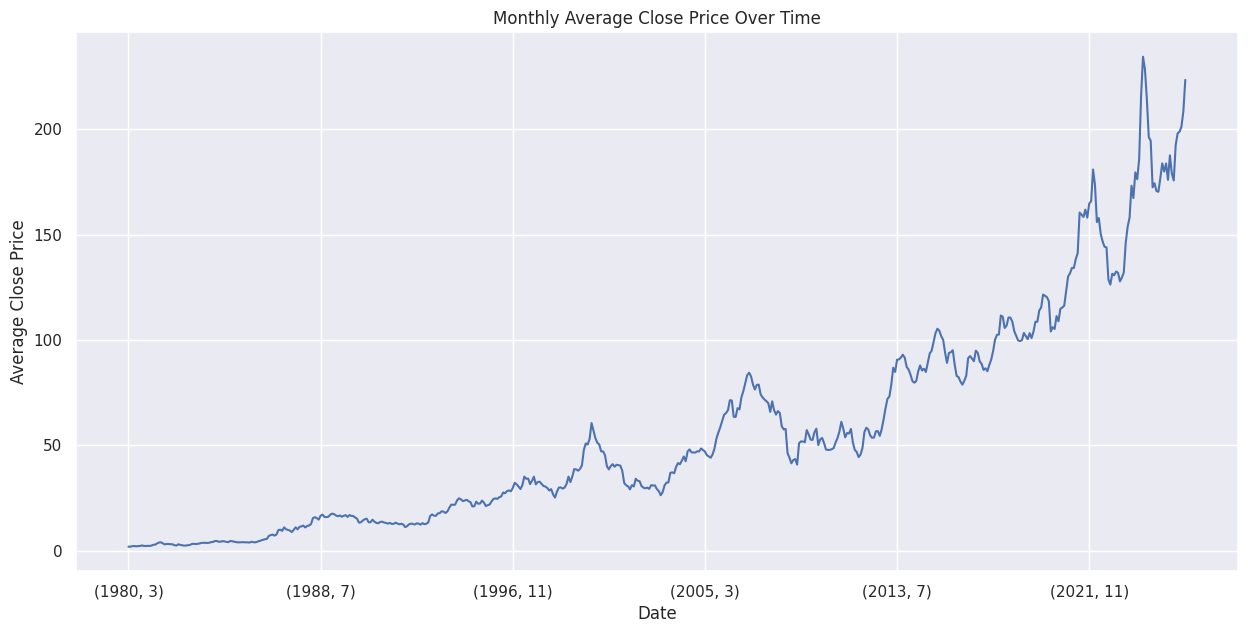

In [23]:
monthly_avg_close = df.groupby(['Year', 'Month'])['Close'].mean()

plt.figure(figsize=(15, 7))
monthly_avg_close.plot()
plt.title('Monthly Average Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Average Close Price')
plt.grid(True)
plt.show()

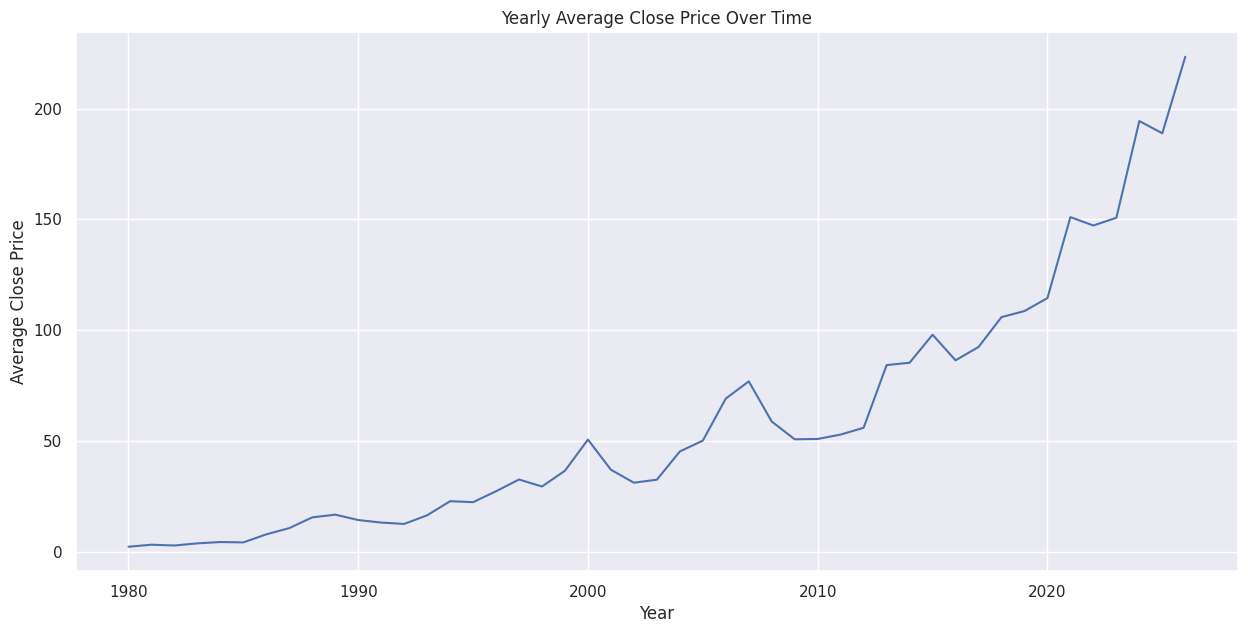

In [24]:
yearly_avg_close = df.groupby('Year')['Close'].mean()

plt.figure(figsize=(15, 7))
yearly_avg_close.plot()
plt.title('Yearly Average Close Price Over Time')
plt.xlabel('Year')
plt.ylabel('Average Close Price')
plt.grid(True)
plt.show()

# Statistical Analsyis

--- 0. QUANTITATIVE SETUP (ENGINEERING RETURNS) ---
 Baseline Returns Calculated: Analyzed 11,507 trading days.

--- 1. THE 'BLACK SWAN' TEST (NORMALITY DIAGNOSTIC) ---
Shapiro-Wilk P-Value: 2.5405e-37
 Insight: Toyota's returns are NOT normally distributed. The data contains 'Fat Tails'.
   -> Standard risk models (like basic Standard Deviation) will severely underestimate crash risks.

--- 2. ASYMMETRIC RISK PROFILING (SKEWNESS & KURTOSIS) ---
Mathematical Skewness: 0.614
   -> Positive Skew: The upside rallies are actually more extreme than the downward crashes.
Excess Kurtosis: 7.993
   -> Leptokurtic (Fat Tails): Extreme outliers happen significantly more often than normal math expects.


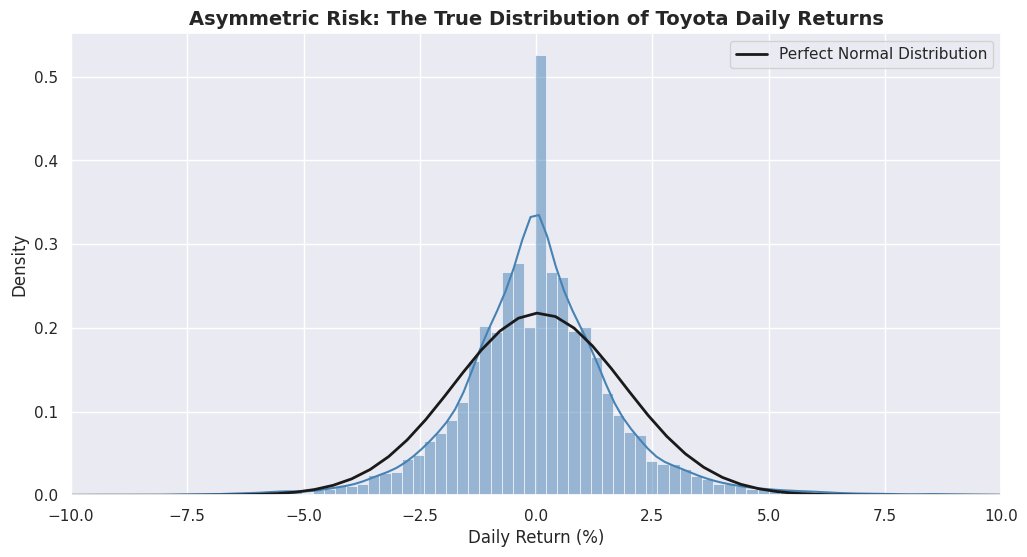


--- 3. LONG-TERM STATIONARITY TEST (AUGMENTED DICKEY-FULLER) ---
ADF Test Statistic: -43.1123
P-Value: 0.0000e+00
 Insight: The Daily Returns are strictly 'Stationary'.
   -> Mathematical translation: The stock's volatility profile does not change over decades.
   -> This means the dataset is mathematically safe to feed into Predictive Modeling algorithms.


In [25]:
import scipy.stats as stats
from statsmodels.tsa.stattools import adfuller


print("--- 0. QUANTITATIVE SETUP (ENGINEERING RETURNS) ---")
# Statistical tests cannot be run on raw prices because prices trend upwards over 40 years.
# We MUST calculate the Daily Percentage Return to stabilize the data.

df['Daily_Return_%'] = df['Close'].pct_change() * 100
df_clean = df.dropna(subset=['Daily_Return_%']).copy()

print(f" Baseline Returns Calculated: Analyzed {len(df_clean):,} trading days.")


print("\n--- 1. THE 'BLACK SWAN' TEST (NORMALITY DIAGNOSTIC) ---")
# Hypothesis: Do Toyota's daily returns follow a perfect normal distribution (Bell Curve)?
# If not, extreme market crashes happen far more frequently than standard models predict.

# We run the Shapiro-Wilk test on a sample (due to size limits of the test, we sample 4000 random days)
sample_returns = df_clean['Daily_Return_%'].sample(n=4000, random_state=42)
stat_shapiro, p_val_shapiro = stats.shapiro(sample_returns)

print(f"Shapiro-Wilk P-Value: {p_val_shapiro:.4e}")
if p_val_shapiro < 0.05:
    print(" Insight: Toyota's returns are NOT normally distributed. The data contains 'Fat Tails'.")
    print("   -> Standard risk models (like basic Standard Deviation) will severely underestimate crash risks.")
else:
    print(" Insight: The returns perfectly follow a normal distribution.")


print("\n--- 2. ASYMMETRIC RISK PROFILING (SKEWNESS & KURTOSIS) ---")
# A standard Bell Curve has a Skewness of 0 and a Kurtosis of 3.
# Let's mathematically measure the exact shape of Toyota's trading history.

skewness = stats.skew(df_clean['Daily_Return_%'])
kurtosis = stats.kurtosis(df_clean['Daily_Return_%']) # Fisher's definition sets normal at 0

print(f"Mathematical Skewness: {skewness:.3f}")
if skewness < 0:
    print("   -> Negative Skew: The worst crashes are more violent than the best rallies (Panic is faster than greed).")
else:
    print("   -> Positive Skew: The upside rallies are actually more extreme than the downward crashes.")

print(f"Excess Kurtosis: {kurtosis:.3f}")
if kurtosis > 0:
    print("   -> Leptokurtic (Fat Tails): Extreme outliers happen significantly more often than normal math expects.")

# Visualizing the True Distribution vs Expectation
plt.figure(figsize=(12, 6))
sns.histplot(df_clean['Daily_Return_%'], bins=150, kde=True, color='steelblue', stat="density")

# Overlaying the theoretical Normal Distribution
mu, std = df_clean['Daily_Return_%'].mean(), df_clean['Daily_Return_%'].std()
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2, label='Perfect Normal Distribution')
plt.title('Asymmetric Risk: The True Distribution of Toyota Daily Returns', fontsize=14, fontweight='bold')
plt.xlabel('Daily Return (%)', fontsize=12)
plt.xlim(-10, 10) # Zooming in to exclude insane 1-day anomalies for clarity
plt.legend()
plt.show()


print("\n--- 3. LONG-TERM STATIONARITY TEST (AUGMENTED DICKEY-FULLER) ---")
# Does Toyota's stock exhibit mean-reverting properties,
# or is it strictly momentum-driven over the last 46 years?

adf_result = adfuller(df_clean['Daily_Return_%'])

print(f"ADF Test Statistic: {adf_result[0]:.4f}")
print(f"P-Value: {adf_result[1]:.4e}")

if adf_result[1] < 0.05:
    print(" Insight: The Daily Returns are strictly 'Stationary'.")
    print("   -> Mathematical translation: The stock's volatility profile does not change over decades.")
    print("   -> This means the dataset is mathematically safe to feed into Predictive Modeling algorithms.")
else:
    print(" Insight: The data is non-stationary. Predictive algorithms will likely fail due to regime shifts.")

# Advance Analysis | Tail Risk

--- 1. VOLATILITY CLUSTERING (ARCH EFFECT DIAGNOSTIC) ---
Ljung-Box P-Value (Squared Returns): 0.0000e+00
🚨 Insight: Strong Volatility Clustering detected (ARCH Effects present).
   -> Mathematical translation: High volatility today guarantees high volatility tomorrow. The market has distinct 'calm' and 'panic' regimes.

--- 2. EXTREME TAIL RISK (VaR & CVaR) ---
📉 99% Value at Risk (VaR): -4.60%
   -> Expectation: On 99 out of 100 trading days, Toyota will NOT drop more than 4.60%.
💥 99% Conditional VaR (Expected Shortfall): -6.30%
   -> Expectation: On that 1 terrible day where VaR is breached, the average expected crash is 6.30%.


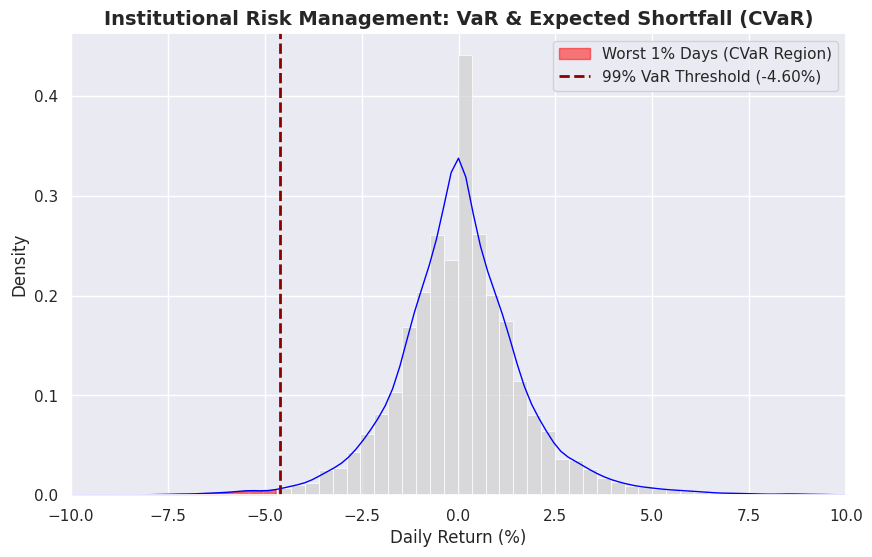


--- 3. TEMPORAL MEMORY & MOMENTUM (ACF / PACF) ---


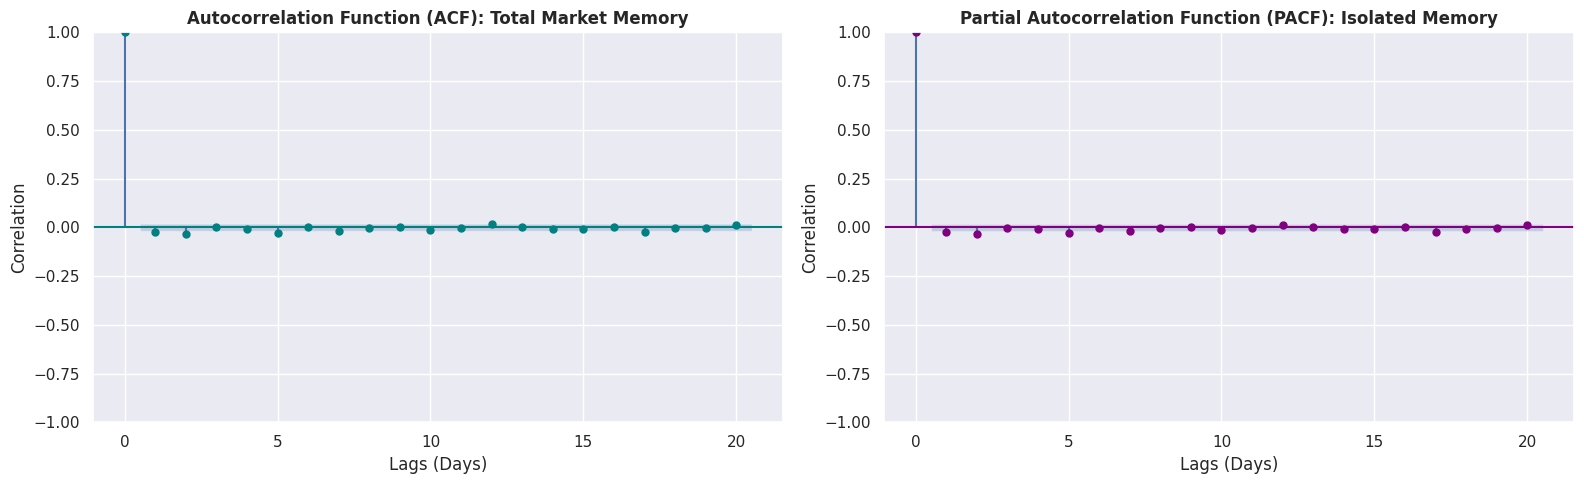

In [26]:
import scipy.stats as stats
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

print("--- 1. VOLATILITY CLUSTERING (ARCH EFFECT DIAGNOSTIC) ---")
# Hypothesis: Market volatility happens in "clusters".
# We test this by looking at the autocorrelation of the SQUARED daily returns.

# Square the returns to represent absolute magnitude/volatility
squared_returns = df_clean['Daily_Return_%']**2

# Run Ljung-Box test on squared returns for the first 10 lags
ljung_box_arch = acorr_ljungbox(squared_returns, lags=[10], return_df=True)
p_val_arch = ljung_box_arch['lb_pvalue'].iloc[0]

print(f"Ljung-Box P-Value (Squared Returns): {p_val_arch:.4e}")
if p_val_arch < 0.05:
    print("🚨 Insight: Strong Volatility Clustering detected (ARCH Effects present).")
    print("   -> Mathematical translation: High volatility today guarantees high volatility tomorrow. The market has distinct 'calm' and 'panic' regimes.")
else:
    print("✅ Insight: No volatility clustering. Variance is randomly distributed over time.")


print("\n--- 2. EXTREME TAIL RISK (VaR & CVaR) ---")
# Portfolio Managers need to know the worst-case scenario.
# We calculate the 99% Confidence Value at Risk (VaR) and Expected Shortfall (CVaR).

# 99% VaR: The threshold where the worst 1% of days begin.
var_99 = np.percentile(df_clean['Daily_Return_%'], 1)

# 99% CVaR (Expected Shortfall): The average return of that worst 1% of days.
cvar_99 = df_clean[df_clean['Daily_Return_%'] <= var_99]['Daily_Return_%'].mean()

print(f"📉 99% Value at Risk (VaR): {var_99:.2f}%")
print(f"   -> Expectation: On 99 out of 100 trading days, Toyota will NOT drop more than {abs(var_99):.2f}%.")

print(f"💥 99% Conditional VaR (Expected Shortfall): {cvar_99:.2f}%")
print(f"   -> Expectation: On that 1 terrible day where VaR is breached, the average expected crash is {abs(cvar_99):.2f}%.")

# Visualizing the Tail Risk
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['Daily_Return_%'], bins=100, color='lightgray', stat='density', kde=False)
sns.kdeplot(df_clean['Daily_Return_%'], color='blue', linewidth=1)

# Shade the CVaR tail region
x_kd = plt.gca().lines[0].get_xdata()
y_kd = plt.gca().lines[0].get_ydata()
plt.fill_between(x_kd, y_kd, where=(x_kd <= var_99), color='red', alpha=0.5, label=f'Worst 1% Days (CVaR Region)')

plt.axvline(var_99, color='darkred', linestyle='--', linewidth=2, label=f'99% VaR Threshold ({var_99:.2f}%)')
plt.title('Institutional Risk Management: VaR & Expected Shortfall (CVaR)', fontsize=14, fontweight='bold')
plt.xlabel('Daily Return (%)', fontsize=12)
plt.xlim(-10, 10)
plt.legend()
plt.show()


print("\n--- 3. TEMPORAL MEMORY & MOMENTUM (ACF / PACF) ---")
# Hypothesis: Does yesterday's stock movement mathematically predict today's movement?
# We plot the Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF).

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# ACF: Direct correlation with previous days
plot_acf(df_clean['Daily_Return_%'], lags=20, ax=ax1, color='teal', alpha=0.05)
ax1.set_title('Autocorrelation Function (ACF): Total Market Memory', fontweight='bold')
ax1.set_xlabel('Lags (Days)')
ax1.set_ylabel('Correlation')

# PACF: Direct correlation isolating the intermediate days
plot_pacf(df_clean['Daily_Return_%'], lags=20, ax=ax2, color='purple', alpha=0.05)
ax2.set_title('Partial Autocorrelation Function (PACF): Isolated Memory', fontweight='bold')
ax2.set_xlabel('Lags (Days)')
ax2.set_ylabel('Correlation')

plt.tight_layout()
plt.show()

## Importing arch

In [27]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 12.8 MB/s eta 0:00:00


# Volatility Modeling & Stochastic

--- 1. CONDITIONAL VOLATILITY (GARCH MODELING) ---
📊 GARCH(1,1) Model Parameters:
mu          0.611941
omega       3.828699
alpha[1]    0.069610
beta[1]     0.921287
Name: params, dtype: float64


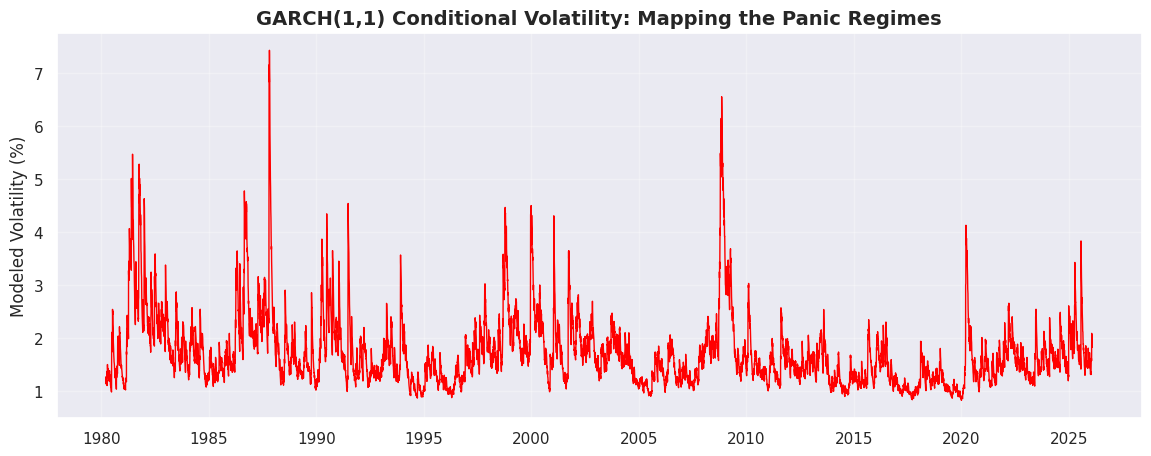


--- 2. HIDDEN MARKOV MODEL (REGIME SWITCHING) ---


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


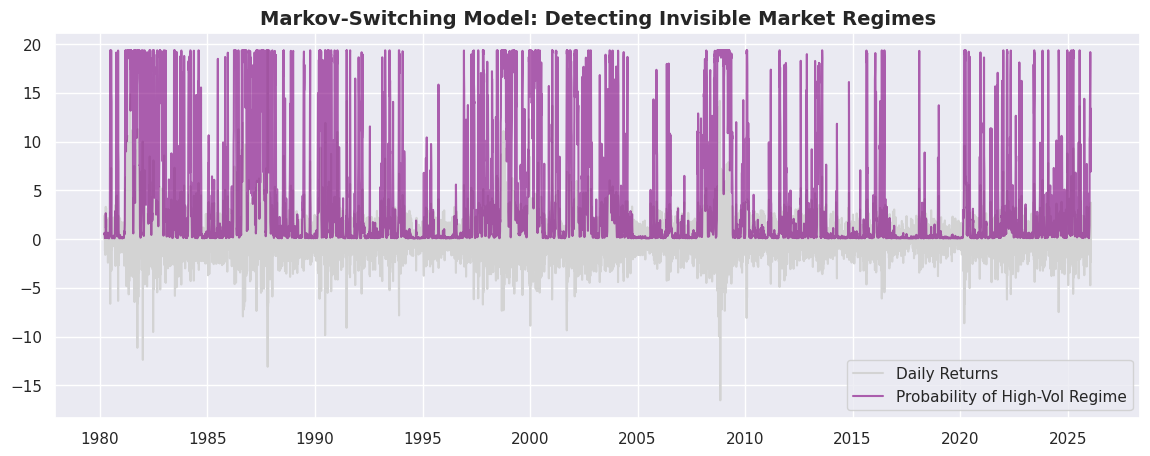


--- 3. MONTE CARLO SIMULATION (GEOMETRIC BROWNIAN MOTION) ---
✅ Monte Carlo Simulation Complete: 1,000 future paths generated for the next 252 days.
🔮 Expected Mean Price: ¥263.60
📉 5th Percentile (Worst Case): ¥158.95
📈 95th Percentile (Best Case): ¥407.16


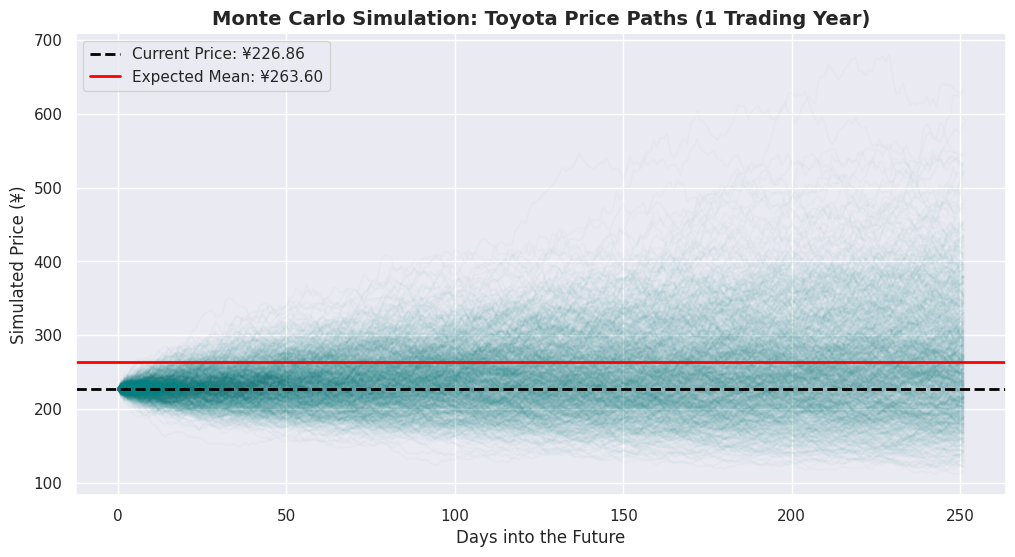

In [28]:
import statsmodels.api as sm
from arch import arch_model

print("--- 1. CONDITIONAL VOLATILITY (GARCH MODELING) ---")
# We are deploy a standard GARCH(1,1) model.
# Rescaling returns to avoid optimization convergence warnings in the solver
scaled_returns = df_clean['Daily_Return_%'] * 10

# Fitting the GARCH(1,1) model assuming a constant mean and normal residuals
garch = arch_model(scaled_returns, vol='Garch', p=1, q=1, rescale=False)
garch_fitted = garch.fit(disp='off')

print("📊 GARCH(1,1) Model Parameters:")
print(garch_fitted.params)

# Extracting the conditional volatility generated by the model
df_clean['Conditional_Volatility'] = garch_fitted.conditional_volatility / 10

plt.figure(figsize=(14, 5))
plt.plot(df_clean.index, df_clean['Conditional_Volatility'], color='red', linewidth=1)
plt.title('GARCH(1,1) Conditional Volatility: Mapping the Panic Regimes', fontsize=14, fontweight='bold')
plt.ylabel('Modeled Volatility (%)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()


print("\n--- 2. HIDDEN MARKOV MODEL (REGIME SWITCHING) ---")
# Toyota operates in two distinct, invisible mathematical states.
# as we will use a Markov Regression to detect a Low-Variance state and a High-Variance state.

# Fitting a Markov-Switching Dynamic Regression model with 2 regimes
# as allowing the variance to switch between regimes (switching_variance=True)
markov_model = sm.tsa.MarkovRegression(df_clean['Daily_Return_%'].dropna(), k_regimes=2, trend='c', switching_variance=True)
markov_results = markov_model.fit()

# Extracting the smoothed probability of being in Regime 1 (High Volatility Regime)
df_clean['Regime_1_Probability'] = markov_results.smoothed_marginal_probabilities[1]

plt.figure(figsize=(14, 5))
plt.plot(df_clean.index, df_clean['Daily_Return_%'], color='lightgray', label='Daily Returns')
# Overlaying the probability of being in the "Panic" regime
plt.plot(df_clean.index, df_clean['Regime_1_Probability'] * df_clean['Daily_Return_%'].max(),
         color='purple', alpha=0.6, label='Probability of High-Vol Regime')
plt.title('Markov-Switching Model: Detecting Invisible Market Regimes', fontsize=14, fontweight='bold')
plt.legend()
plt.show()

print("\n--- 3. MONTE CARLO SIMULATION (GEOMETRIC BROWNIAN MOTION) ---")
# We will simulate 1,000 possible futures for Toyota's stock price over the next 252 trading days.
# GBM Formula: S_t = S_{t-1} * exp((mu - 0.5 * sigma^2) * dt + sigma * sqrt(dt) * Z)

# Calculating historical drift (mu) and volatility (sigma) using raw decimal returns
decimal_returns = df_clean['Daily_Return_%'] / 100
mu = decimal_returns.mean()
sigma = decimal_returns.std()

# Simulationing Parameters
days_to_simulate = 252 # One trading year
num_simulations = 1000
last_price = df_clean['Close'].iloc[-1]

# Initializing the simulation array
simulation_df = np.zeros((days_to_simulate, num_simulations))
simulation_df[0] = last_price

# Running the Stochastic Simulation
for x in range(1, days_to_simulate):
    # Z is a random normal shock
    Z = np.random.normal(0, 1, num_simulations)
    # Applying the GBM mathematical model
    daily_drift = mu - (0.5 * sigma**2)
    daily_shock = sigma * Z
    simulation_df[x] = simulation_df[x-1] * np.exp(daily_drift + daily_shock)

print(f"✅ Monte Carlo Simulation Complete: 1,000 future paths generated for the next {days_to_simulate} days.")

# Calculating the expected value (mean) and the 95% confidence intervals
expected_price = np.mean(simulation_df[-1])
percentile_5 = np.percentile(simulation_df[-1], 5)
percentile_95 = np.percentile(simulation_df[-1], 95)

print(f"🔮 Expected Mean Price: ¥{expected_price:,.2f}")
print(f"📉 5th Percentile (Worst Case): ¥{percentile_5:,.2f}")
print(f"📈 95th Percentile (Best Case): ¥{percentile_95:,.2f}")

# Visualizing the Multiverse of Future Prices
plt.figure(figsize=(12, 6))
plt.plot(simulation_df, color='teal', alpha=0.02) # Plot all 1,000 paths lightly
plt.axhline(last_price, color='black', linestyle='--', linewidth=2, label=f'Current Price: ¥{last_price:,.2f}')
plt.axhline(expected_price, color='red', linestyle='-', linewidth=2, label=f'Expected Mean: ¥{expected_price:,.2f}')
plt.title('Monte Carlo Simulation: Toyota Price Paths (1 Trading Year)', fontsize=14, fontweight='bold')
plt.xlabel('Days into the Future', fontsize=12)
plt.ylabel('Simulated Price (¥)', fontsize=12)
plt.legend()
plt.show()

# Time-Series Analysis

--- 1. MACRO-TREND SMOOTHING (MOVING AVERAGES) ---


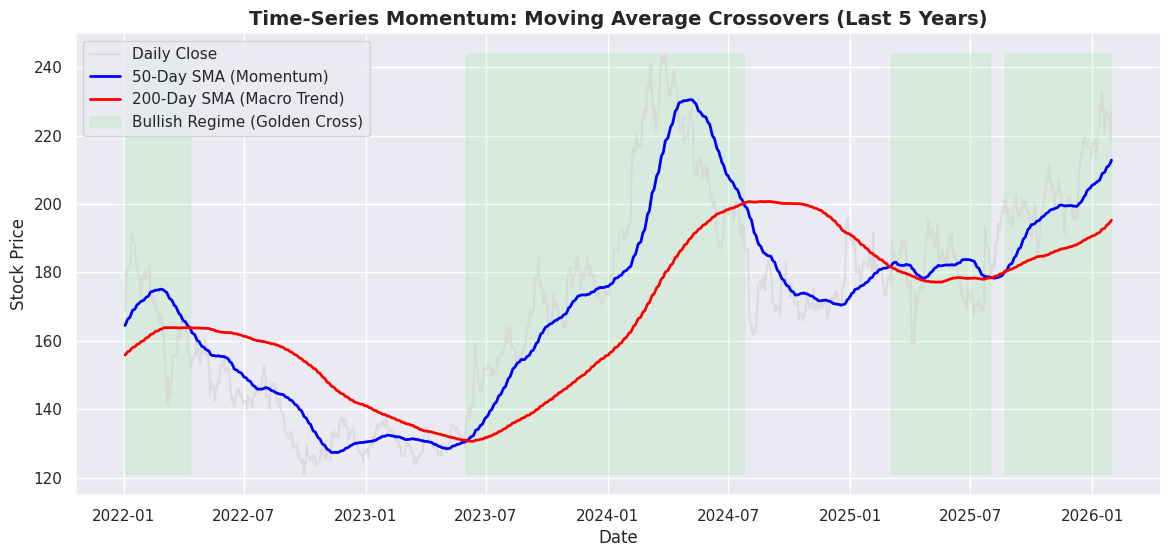


--- 2. SEASONAL DECOMPOSITION (BUSINESS CYCLES) ---


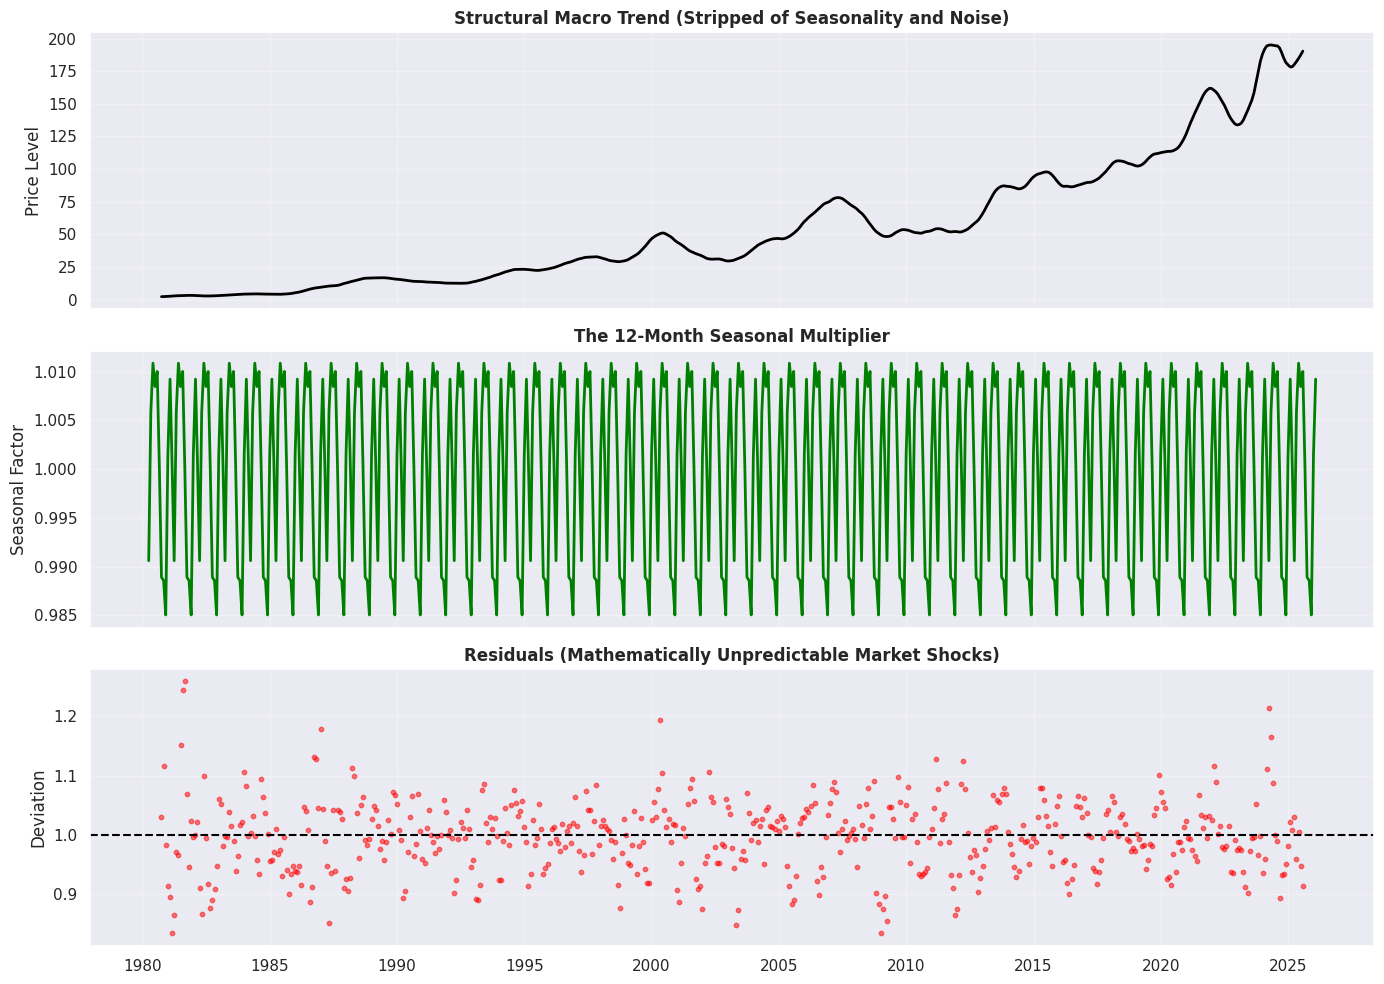


--- 3. ROLLING VOLATILITY (30-DAY WINDOW) ---


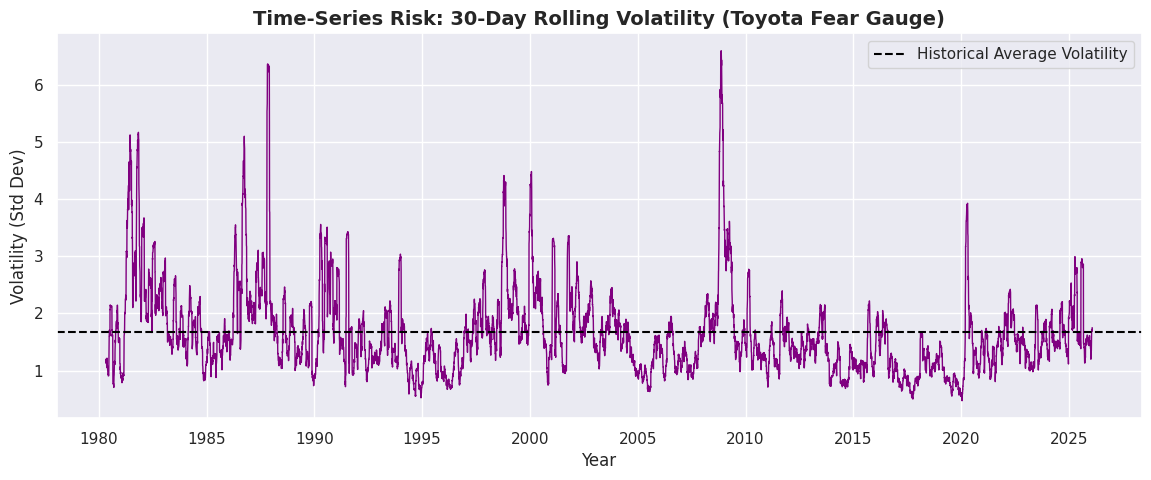

In [29]:
from statsmodels.tsa.seasonal import seasonal_decompose

print("--- 1. MACRO-TREND SMOOTHING (MOVING AVERAGES) ---")
# Raw daily prices are too noisy for structural trend analysis.
# We are calculating the 50-Day (Short-Term) and 200-Day (Long-Term) Simple Moving Averages.

df['SMA_50'] = df['Close'].rolling(window=50).mean()
df['SMA_200'] = df['Close'].rolling(window=200).mean()

# A 'Golden Cross' occurs when the 50-Day SMA crosses ABOVE the 200-Day SMA (Bullish Signal)
# A 'Death Cross' occurs when the 50-Day SMA crosses BELOW the 200-Day SMA (Bearish Signal)
df['Signal'] = 0
df.loc[df['SMA_50'] > df['SMA_200'], 'Signal'] = 1  # Bullish Regime
df.loc[df['SMA_50'] < df['SMA_200'], 'Signal'] = -1 # Bearish Regime

# Visualizing the last 5 years of the dataset to see the crossovers clearly
recent_ts = df.last('5Y')

plt.figure(figsize=(14, 6))
plt.plot(recent_ts.index, recent_ts['Close'], color='lightgray', label='Daily Close', alpha=0.6)
plt.plot(recent_ts.index, recent_ts['SMA_50'], color='blue', linewidth=2, label='50-Day SMA (Momentum)')
plt.plot(recent_ts.index, recent_ts['SMA_200'], color='red', linewidth=2, label='200-Day SMA (Macro Trend)')

# Highlight Golden Cross (Bullish) Regimes
plt.fill_between(recent_ts.index, recent_ts['Close'].min(), recent_ts['Close'].max(),
                 where=(recent_ts['Signal'] == 1), color='lightgreen', alpha=0.2, label='Bullish Regime (Golden Cross)')

plt.title('Time-Series Momentum: Moving Average Crossovers (Last 5 Years)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Stock Price', fontsize=12)
plt.legend(loc='upper left')
plt.show()


print("\n--- 2. SEASONAL DECOMPOSITION (BUSINESS CYCLES) ---")
# Does Toyota's stock have a seasonal cycle? (e.g., Do car sales in Spring boost the stock?)
# We must resample the daily data to Monthly Averages to run a clean decomposition.

# Resample to Month-End ('ME') average closing prices
monthly_toyota = df['Close'].resample('ME').mean().dropna()

# Running a Multiplicative Seasonal Decomposition (assuming a 12-month cycle)
# Multiplicative is used because the stock price grows exponentially over 40 years.
decomposition = seasonal_decompose(monthly_toyota, model='multiplicative', period=12)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# 1. The Macro Trend (Noise removed)
ax1.plot(decomposition.trend, color='black', linewidth=2)
ax1.set_title('Structural Macro Trend (Stripped of Seasonality and Noise)', fontweight='bold')
ax1.set_ylabel('Price Level')
ax1.grid(True, alpha=0.3)

# 2. The Annual Seasonality
ax2.plot(decomposition.seasonal, color='green', linewidth=2)
ax2.set_title('The 12-Month Seasonal Multiplier', fontweight='bold')
ax2.set_ylabel('Seasonal Factor')
ax2.grid(True, alpha=0.3)

# 3. The Residuals (Chaos/Crashes)
ax3.scatter(monthly_toyota.index, decomposition.resid, color='red', alpha=0.5, s=10)
ax3.axhline(1, color='black', linestyle='--')
ax3.set_title('Residuals (Mathematically Unpredictable Market Shocks)', fontweight='bold')
ax3.set_ylabel('Deviation')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


print("\n--- 3. ROLLING VOLATILITY (30-DAY WINDOW) ---")
# We are calculating the 30-day rolling standard deviation of the daily returns.

df['Rolling_Vol_30D'] = df['Daily_Return_%'].rolling(window=30).std()

plt.figure(figsize=(14, 5))
plt.plot(df.index, df['Rolling_Vol_30D'], color='purple', linewidth=1)
plt.axhline(df['Rolling_Vol_30D'].mean(), color='black', linestyle='--', label='Historical Average Volatility')
plt.title('Time-Series Risk: 30-Day Rolling Volatility (Toyota Fear Gauge)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Volatility (Std Dev)', fontsize=12)
plt.legend()
plt.show()

## Algorithic Time-Series & Signal Processing Analysis

--- 1. MAXIMUM DRAWDOWN (CAPITAL PRESERVATION RISK) ---
📉 Historical Maximum Drawdown: -60.34%


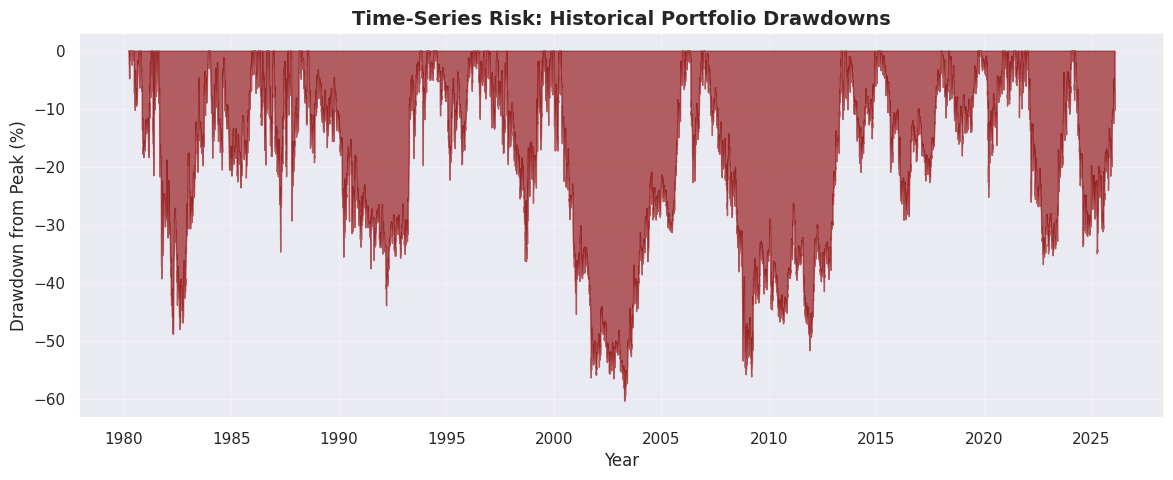


--- 2. ALGORITHMIC OSCILLATORS (MACD & RSI) ---


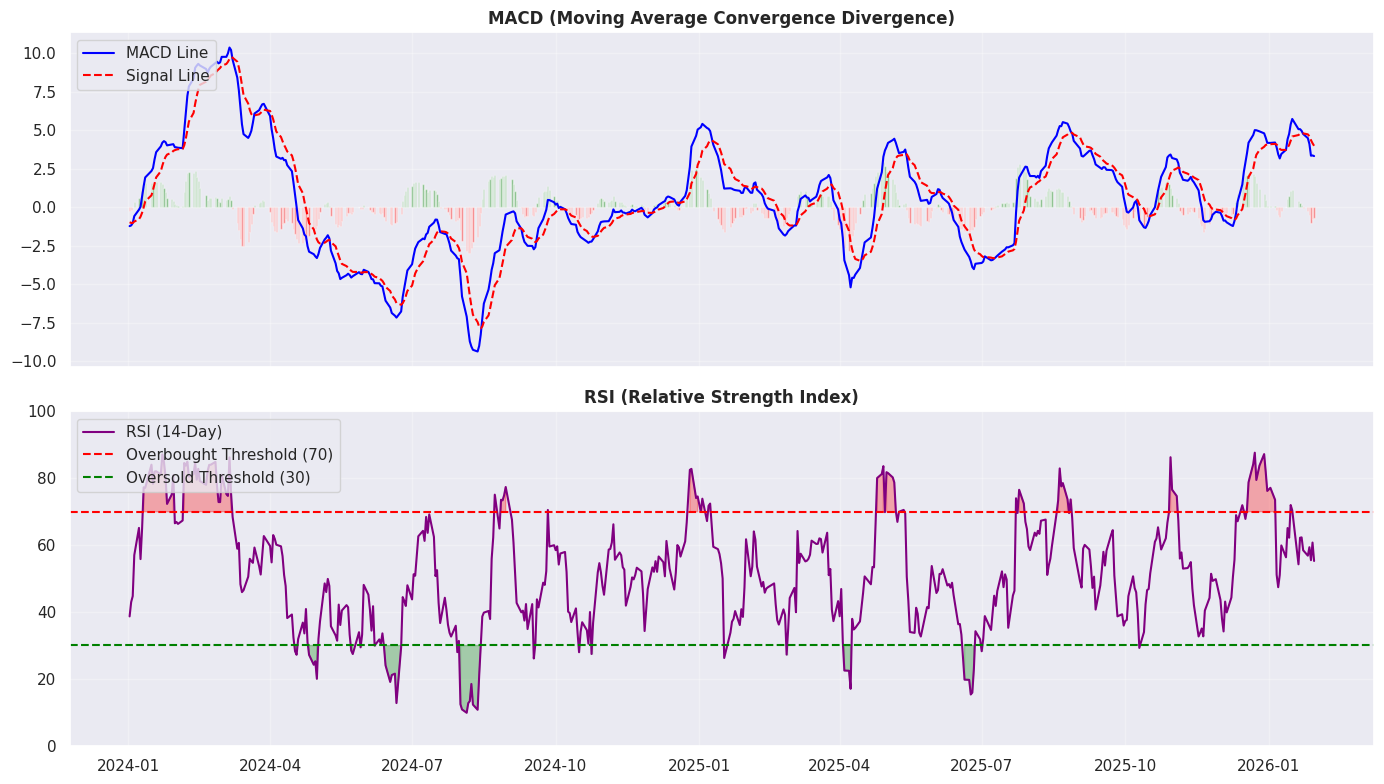


--- 3. SPECTRAL ANALYSIS (FAST FOURIER TRANSFORM) ---


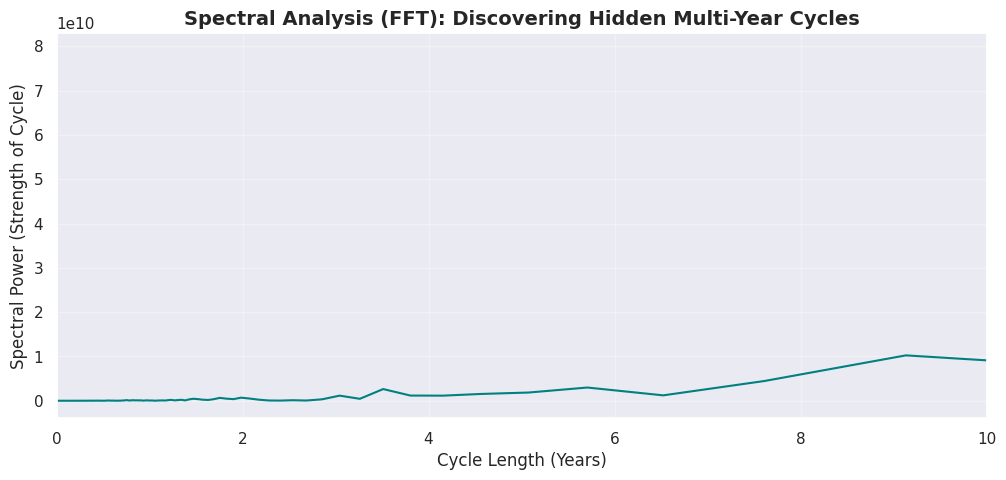

 FFT Discovery: The strongest hidden macro-cycle in this asset lasts approximately 45.67 years.


In [31]:
print("--- 1. MAXIMUM DRAWDOWN (CAPITAL PRESERVATION RISK) ---")
# A "Drawdown" measures the decline from a historical peak.
# Institutional investors care more about Maximum Drawdown (MDD) than average returns.

# Calculating the running cumulative maximum price
df['Cumulative_Max'] = df['Close'].cummax()

# Calculating the percentage drop from the highest peak
df['Drawdown_%'] = ((df['Close'] - df['Cumulative_Max']) / df['Cumulative_Max']) * 100

# Finding the worst historical drawdown
max_drawdown = df['Drawdown_%'].min()
print(f"📉 Historical Maximum Drawdown: {max_drawdown:.2f}%")

plt.figure(figsize=(14, 5))
plt.fill_between(df.index, df['Drawdown_%'], 0, color='darkred', alpha=0.6)
plt.title('Time-Series Risk: Historical Portfolio Drawdowns', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Drawdown from Peak (%)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()


print("\n--- 2. ALGORITHMIC OSCILLATORS (MACD & RSI) ---")
# We will engineer the MACD (Moving Average Convergence Divergence) and RSI (Relative Strength Index).

# --- MACD Calculation ---

# 12-Day and 26-Day Exponential Moving Averages (EMA)
ema_12 = df['Close'].ewm(span=12, adjust=False).mean()
ema_26 = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = ema_12 - ema_26
df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean() # 9-Day EMA of MACD
df['MACD_Histogram'] = df['MACD'] - df['MACD_Signal']

# --- RSI Calculation ---

# 14-Day Relative Strength Index
delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df['RSI'] = 100 - (100 / (1 + rs))

# Plotting the last 3 years to see the algorithmic signals clearly
recent_algo = df.last('3Y')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# MACD Plot
ax1.plot(recent_algo.index, recent_algo['MACD'], color='blue', label='MACD Line')
ax1.plot(recent_algo.index, recent_algo['MACD_Signal'], color='red', linestyle='--', label='Signal Line')
ax1.bar(recent_algo.index, recent_algo['MACD_Histogram'], color=np.where(recent_algo['MACD_Histogram'] > 0, 'green', 'red'), alpha=0.5)
ax1.set_title('MACD (Moving Average Convergence Divergence)', fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# RSI Plot
ax2.plot(recent_algo.index, recent_algo['RSI'], color='purple', label='RSI (14-Day)')
ax2.axhline(70, color='red', linestyle='--', label='Overbought Threshold (70)')
ax2.axhline(30, color='green', linestyle='--', label='Oversold Threshold (30)')
ax2.fill_between(recent_algo.index, recent_algo['RSI'], 70, where=(recent_algo['RSI'] >= 70), color='red', alpha=0.3)
ax2.fill_between(recent_algo.index, recent_algo['RSI'], 30, where=(recent_algo['RSI'] <= 30), color='green', alpha=0.3)
ax2.set_title('RSI (Relative Strength Index)', fontweight='bold')
ax2.set_ylim(0, 100)
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


print("\n--- 3. SPECTRAL ANALYSIS (FAST FOURIER TRANSFORM) ---")
# Seasonal Decomposition assumes a fixed 12-month calendar cycle.
# Using the Fast Fourier Transform (FFT) to convert the time-series into the frequency domain,
# mathematically extracting ANY hidden cyclical frequencies (e.g., a 3.5-year macro cycle).

# Here we are must detrend the data first (subtract the mean) so the zero-frequency doesn't dominate
detrended_close = df['Close'].dropna() - df['Close'].dropna().mean()

# Computing the FFT
fft_values = np.fft.fft(detrended_close.values)
fft_power = np.abs(fft_values) ** 2 # Power Spectrum

# Computing frequencies (cycles per trading day)
frequencies = np.fft.fftfreq(len(fft_power))

# Keepping only the positive half of the frequencies
positive_freqs = frequencies[1:len(frequencies)//2]
positive_power = fft_power[1:len(fft_power)//2]

# Converting frequencies to "Days per Cycle" (Period)
periods_in_days = 1 / positive_freqs
# Converting days to "Years per Cycle" (assuming 252 trading days/year)
periods_in_years = periods_in_days / 252

# Plotting the Power Spectrum to find the dominant cycles
plt.figure(figsize=(12, 5))
plt.plot(periods_in_years, positive_power, color='teal')
plt.title('Spectral Analysis (FFT): Discovering Hidden Multi-Year Cycles', fontsize=14, fontweight='bold')
plt.xlabel('Cycle Length (Years)', fontsize=12)
plt.ylabel('Spectral Power (Strength of Cycle)', fontsize=12)
plt.xlim(0, 10)
plt.grid(True, alpha=0.3)
plt.show()

# Finding the mathematically strongest hidden cycle
dominant_index = np.argmax(positive_power)
dominant_cycle_years = periods_in_years[dominant_index]
print(f" FFT Discovery: The strongest hidden macro-cycle in this asset lasts approximately {dominant_cycle_years:.2f} years.")

# Feature Engineering | Quantitative

In [34]:
from sklearn.preprocessing import StandardScaler

print("--- 1. AUTOREGRESSIVE LAGGED FEATURES ---")
# To predict tomorrow, the algorithm needs to know what happened today, yesterday, and the day before.
# Ensuring data is sorted chronologically
df = df.sort_index()

# Creating lagged returns (t-1, t-2, t-3)
df['Return_Lag_1'] = df['Daily_Return_%'].shift(1)
df['Return_Lag_2'] = df['Daily_Return_%'].shift(2)
df['Return_Lag_3'] = df['Daily_Return_%'].shift(3)

# Creating lagged volatility (so the model knows if the market was recently panicking)
df['Vol_Lag_1'] = df['Rolling_Vol_30D'].shift(1)

print(" Engineered: Autoregressive Lags (t-1 to t-3).")


print("\n--- 2. MOMENTUM & OSCILLATOR FEATURES ---")
# We have already calculated MACD and RSI in Phase 5.
# We must shift them by 1 day as well. If we don't, we commit "Look-Ahead Bias"
# (using today's closing metrics to predict today's close, which is cheating).

df['RSI_Lag_1'] = df['RSI'].shift(1)
df['MACD_Hist_Lag_1'] = df['MACD_Histogram'].shift(1)

# Distance from the 200-Day SMA (Is the stock historically overextended?)
df['Dist_From_SMA_200'] = ((df['Close'] - df['SMA_200']) / df['SMA_200']).shift(1)

print(" Engineered: Shifted Momentum Oscillators to prevent Data Leakage.")


print("\n--- 3. DEFINING THE TARGET VARIABLE (Y) ---")
# What is the algorithm actually trying to predict?
# We will frame this as a Classification problem: Will the stock go UP (1) or DOWN (0) tomorrow?

# The Target is tomorrow's actual return direction
df['Target_Next_Day_Direction'] = np.where(df['Daily_Return_%'].shift(-1) > 0, 1, 0)

print(" Engineered: Binary Target Variable (Next Day Direction).")

print("\n--- 4. DATA SANITIZATION & FEATURE SCALING ---")
# Financial data has vastly different scales (e.g., RSI is 0-100, Daily Return is -5 to +5).
# We must standardize the features so the algorithm doesn't overweight large numbers.

# Define the final feature matrix
ml_features = [
    'Return_Lag_1', 'Return_Lag_2', 'Return_Lag_3',
    'Vol_Lag_1', 'RSI_Lag_1', 'MACD_Hist_Lag_1', 'Dist_From_SMA_200'
]

# Drop all NaN rows created by our rolling windows and lagged shifts
ml_df = df.dropna(subset=ml_features + ['Target_Next_Day_Direction', 'Daily_Return_%']).copy()

# Initialize the StandardScaler
scaler = StandardScaler()

# Scale the feature matrix (X)
X_unscaled = ml_df[ml_features]
X_scaled = pd.DataFrame(scaler.fit_transform(X_unscaled), columns=ml_features, index=ml_df.index)

# Define the Target (y)
y = ml_df['Target_Next_Day_Direction']

print(f" Data Sanitized: {len(ml_df):,} viable trading days remaining.")
print(f" Feature Matrix (X) successfully standardized (Mean=0, Variance=1).")

# Preview the final, machine-readable dataset
print("\n Final Scaled Feature Matrix (X) Preview:")
print(X_scaled.tail())

--- 1. AUTOREGRESSIVE LAGGED FEATURES ---
 Engineered: Autoregressive Lags (t-1 to t-3).

--- 2. MOMENTUM & OSCILLATOR FEATURES ---
 Engineered: Shifted Momentum Oscillators to prevent Data Leakage.

--- 3. DEFINING THE TARGET VARIABLE (Y) ---
 Engineered: Binary Target Variable (Next Day Direction).

--- 4. DATA SANITIZATION & FEATURE SCALING ---
 Data Sanitized: 11,308 viable trading days remaining.
 Feature Matrix (X) successfully standardized (Mean=0, Variance=1).

 Final Scaled Feature Matrix (X) Preview:
            Return_Lag_1  Return_Lag_2  Return_Lag_3  Vol_Lag_1  RSI_Lag_1  \
Date                                                                         
2026-01-26     -0.213349     -0.198318      1.762449   0.058203   0.411459   
2026-01-27     -0.189927     -0.213207     -0.198445   0.022745   0.314783   
2026-01-28     -0.392860     -0.189781     -0.213335   0.023240   0.465332   
2026-01-29     -1.300352     -0.392749     -0.189908   0.059237   0.233982   
2026-01-30      

# Machine Learning | Backtesting

--- 1. CHRONOLOGICAL TRAIN/TEST SPLIT ---
 Training Set: 10552 days
 Testing Set: 756 days (Out-of-Sample)

--- 2. TRAINING THE CLASSIFIER ---
✅ Random Forest Classifier successfully trained on historical regimes.

--- 3. ALGORITHMIC EVALUATION (OUT-OF-SAMPLE) ---
 Out-of-Sample Accuracy: 52.25%
 Out-of-Sample Precision: 53.65%

Classification Report:
              precision    recall  f1-score   support

DOWN Day (0)       0.48      0.27      0.34       354
  UP Day (1)       0.54      0.75      0.63       402

    accuracy                           0.52       756
   macro avg       0.51      0.51      0.48       756
weighted avg       0.51      0.52      0.49       756



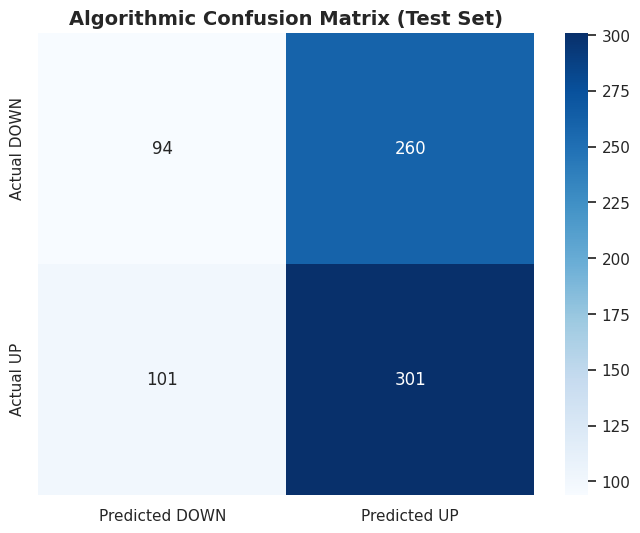


--- 4. FEATURE IMPORTANCE (WHAT DRIVES THE ALGORITHM?) ---


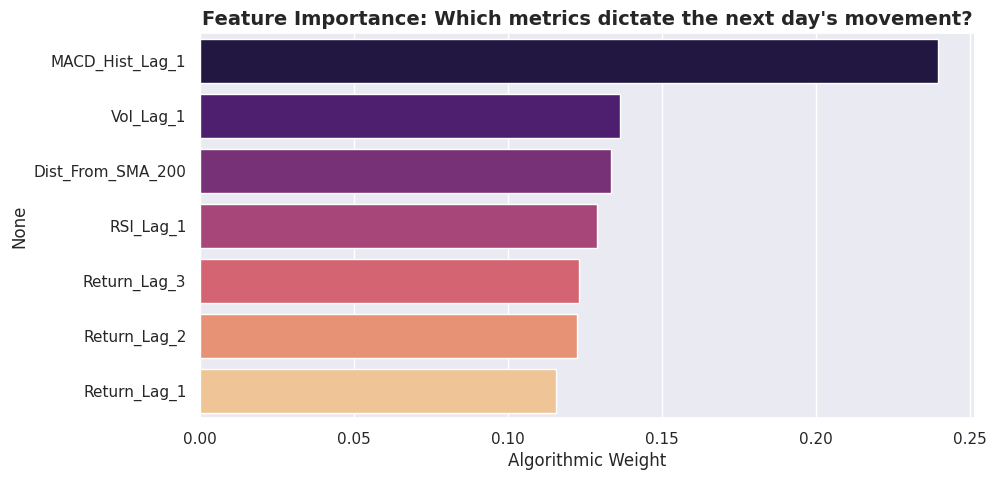


--- 5. ALGORITHMIC STRATEGY BACKTEST ---


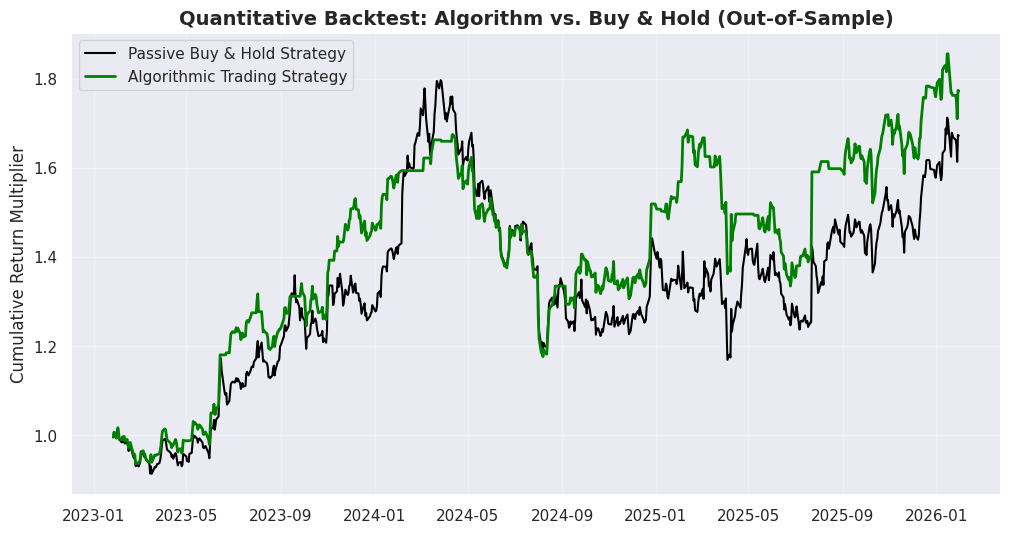

 Passive Buy & Hold Return: 67.19%
 Algorithmic Strategy Return: 77.20%


In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, classification_report, confusion_matrix

print("--- 1. CHRONOLOGICAL TRAIN/TEST SPLIT ---")
# Financial data MUST be split chronologically to prevent look-ahead bias.
# We will train on the historical data and test the algorithm on the last 3 years of trading.

test_trading_days = 252 * 3 # Approx 3 years of trading days
split_index = len(X_scaled) - test_trading_days

X_train = X_scaled.iloc[:split_index]
X_test = X_scaled.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print(f" Training Set: {len(X_train)} days")
print(f" Testing Set: {len(X_test)} days (Out-of-Sample)")


print("\n--- 2. TRAINING THE CLASSIFIER ---")
# Deploying a Random Forest Classifier
# We restrict the max_depth to prevent the model from memorizing the noise in the training data (overfitting).
rf_classifier = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42, class_weight='balanced')
rf_classifier.fit(X_train, y_train)

print("✅ Random Forest Classifier successfully trained on historical regimes.")


print("\n--- 3. ALGORITHMIC EVALUATION (OUT-OF-SAMPLE) ---")
# Forceing the algorithm to predict the unseen Testing Set
ml_predictions = rf_classifier.predict(X_test)

# Calculating standard classification metrics
accuracy = accuracy_score(y_test, ml_predictions)
# Precision is crucial in trading: When the algorithm predicts an UP day, how often is it actually right?
precision = precision_score(y_test, ml_predictions)

print(f" Out-of-Sample Accuracy: {accuracy * 100:.2f}%")
print(f" Out-of-Sample Precision: {precision * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, ml_predictions, target_names=['DOWN Day (0)', 'UP Day (1)']))

# Visualizing the Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, ml_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted DOWN', 'Predicted UP'], yticklabels=['Actual DOWN', 'Actual UP'])
plt.title('Algorithmic Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')
plt.show()

print("\n--- 4. FEATURE IMPORTANCE (WHAT DRIVES THE ALGORITHM?) ---")
importances = pd.Series(rf_classifier.feature_importances_, index=ml_features).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=importances.values, y=importances.index, palette='magma')
plt.title('Feature Importance: Which metrics dictate the next day\'s movement?', fontsize=14, fontweight='bold')
plt.xlabel('Algorithmic Weight', fontsize=12)
plt.show()


print("\n--- 5. ALGORITHMIC STRATEGY BACKTEST ---")
# Does this model actually make money? We will simulate a trading strategy.
# If the model predicts 1 (UP), we hold the stock and capture the daily return.
# If the model predicts 0 (DOWN), we sell and hold cash (0% return that day).

# Extracting the actual daily returns for the test period from the original dataframe
test_returns = df.loc[X_test.index, 'Daily_Return_%'] / 100

# Calculating the Buy & Hold Strategy (Passive Investing)
cumulative_buy_and_hold = (1 + test_returns).cumprod()

# Calculating the Algorithmic Strategy
# Multiply the prediction (1 or 0) by the actual return
algo_returns = ml_predictions * test_returns
cumulative_algo_strategy = (1 + algo_returns).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(cumulative_buy_and_hold.index, cumulative_buy_and_hold, color='black', label='Passive Buy & Hold Strategy')
plt.plot(cumulative_algo_strategy.index, cumulative_algo_strategy, color='green', linewidth=2, label='Algorithmic Trading Strategy')
plt.title('Quantitative Backtest: Algorithm vs. Buy & Hold (Out-of-Sample)', fontsize=14, fontweight='bold')
plt.ylabel('Cumulative Return Multiplier', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Final performance numbers
final_bh = (cumulative_buy_and_hold.iloc[-1] - 1) * 100
final_algo = (cumulative_algo_strategy.iloc[-1] - 1) * 100

print(f" Passive Buy & Hold Return: {final_bh:.2f}%")
print(f" Algorithmic Strategy Return: {final_algo:.2f}%")

# Thank You